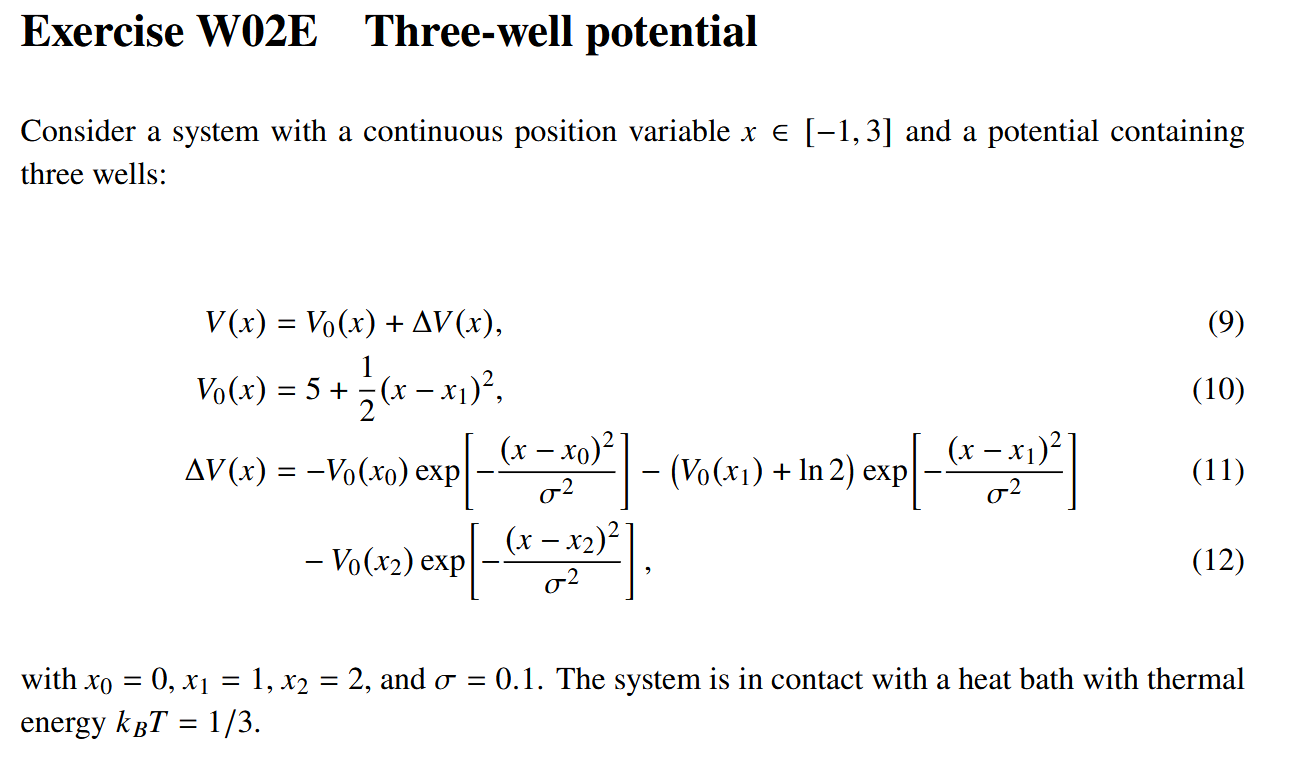
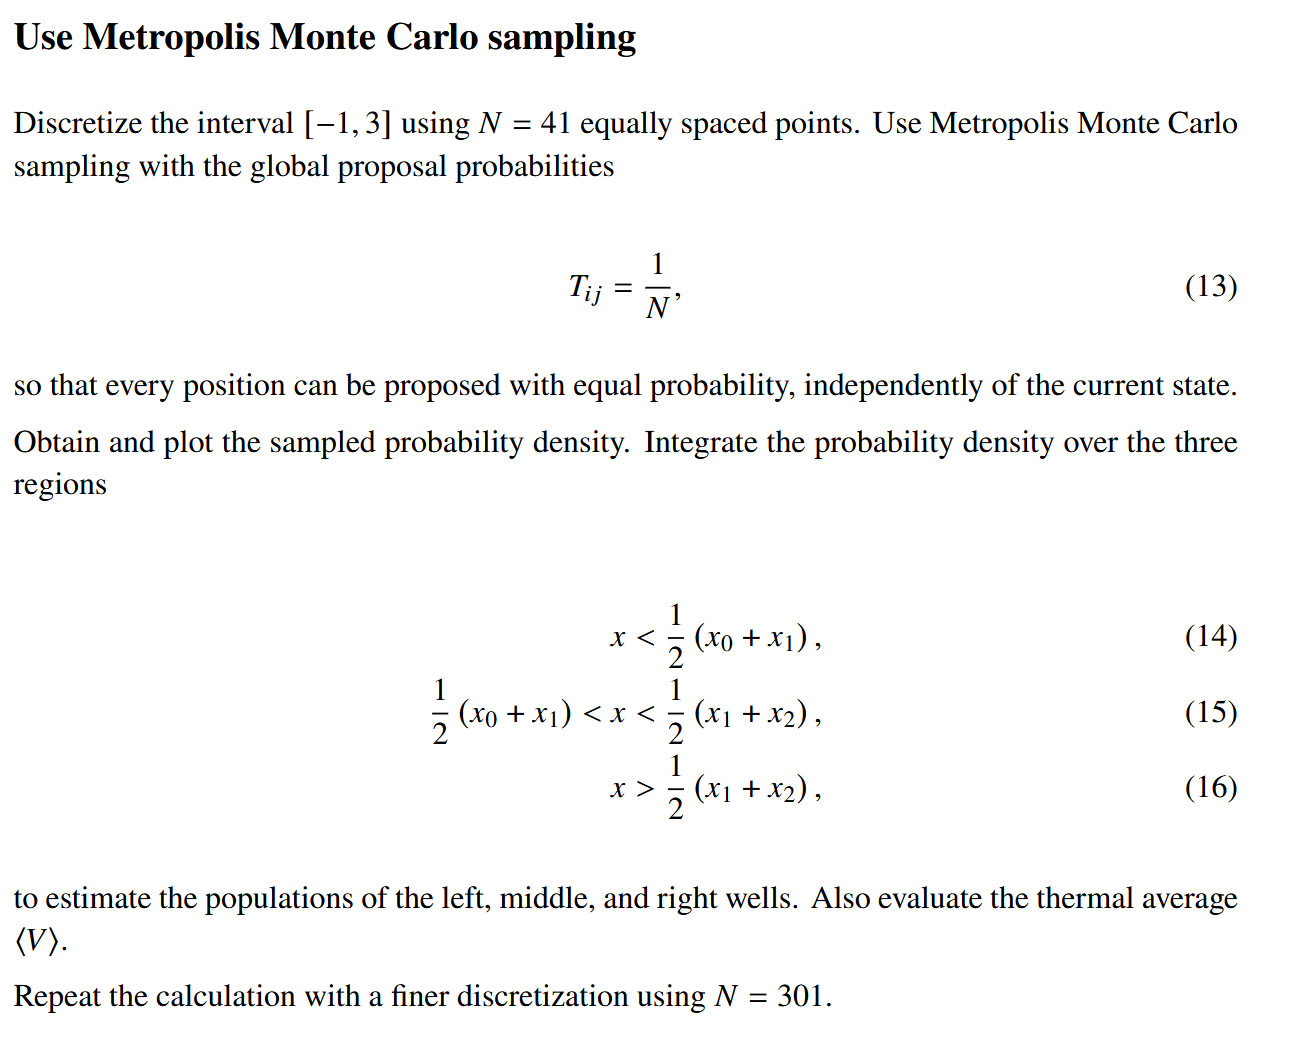

--- Integrals for N=41 ---
Region 1 (x < 0.5): 0.1003
Region 2 (0.5 < x < 1.5): 0.7924
Region 3 (x > 1.5): 0.1073
--- Integrals for N=301 ---
Region 1 (x < 0.5): 0.0887
Region 2 (0.5 < x < 1.5): 0.8056
Region 3 (x > 1.5): 0.1057


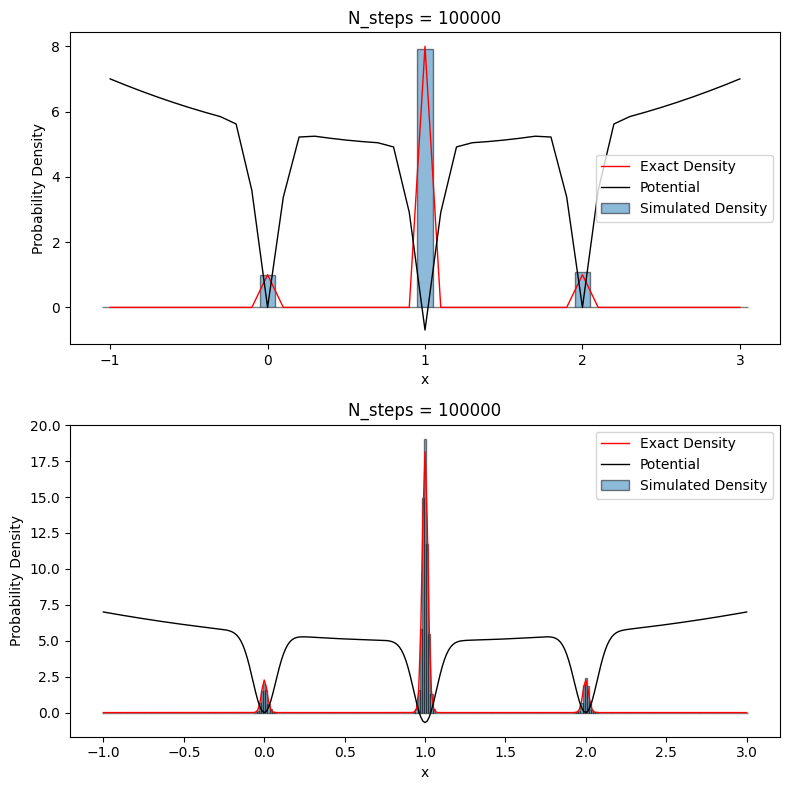

In [9]:
import numpy as np
import matplotlib.pyplot as plt

class DiscretizedSpaceMetro:
    def __init__(self, k=1, x0=0, x1=1, x2=2, sigma=0.1, kbT=1/3, xmin=-1, xmax=3, N_points=41):
        self.k = k
        self.x0 = x0
        self.x1 = x1
        self.x2 = x2
        self.sigma = sigma
        self.kbT = kbT
        self.xmin = xmin
        self.xmax = xmax
        
        self.grid = np.linspace(self.xmin, self.xmax, N_points)
        self.dx = self.grid[1] - self.grid[0] 
        
        self.state = self.grid[0] 

    def V0(self, x):
        return 5 + 1/2*(x - self.x1)**2

    def delta_V(self, x):
        term = lambda xi: np.exp(-(x-xi)**2/self.sigma**2)
        return (-self.V0(self.x0)*term(self.x0) 
                - (self.V0(self.x1) + np.log(2)) * term(self.x1)
                - self.V0(self.x2)* term(self.x2))

    def V(self, x):
        return self.V0(x) + self.delta_V(x)

    def propose(self):
        # Global proposal probabilities (T_ij = 1/N)
        return np.random.choice(self.grid)

    def step(self):
        x_m = self.propose()
        A = min(1.0, np.exp(-1/self.kbT * (self.V(x_m) - self.V(self.state))))
        if np.random.rand() < A:
            self.state = x_m

    def run_simulation(self, n=100_000):
        self.n = n
        history = [self.state]
        for _ in range(n):
            self.step()
            history.append(self.state)

        self.history = np.array(history)
        return self.history

    def integrate_regions(self):
        """
        Integrates the probability density over the three regions defined in the assignment.
        Since it's a Monte Carlo simulation, integrating the probability density 
        over a region is exactly equal to the fraction of samples in that region!
        """
        bound1 = 0.5 * (self.x0 + self.x1) # 0.5
        bound2 = 0.5 * (self.x1 + self.x2) # 1.5
        
        region1 = np.sum(self.history < bound1) / len(self.history)
        region2 = np.sum((self.history >= bound1) & (self.history <= bound2)) / len(self.history)
        region3 = np.sum(self.history > bound2) / len(self.history)
        
        return region1, region2, region3

    def plot(self, ax):
        if not hasattr(self, 'history'): 
            raise Exception('Simulation not run')

        counts = np.array([np.sum(np.isclose(self.history, x)) for x in self.grid])
        
        P_sim = counts / len(self.history)
        density_sim = P_sim / self.dx

        ax.bar(self.grid, density_sim, width=self.dx, facecolor='C0', alpha=0.5, edgecolor='k', label='Simulated Density')

        unnormalized_p = np.exp(-self.V(self.grid) / self.kbT)
        Z = np.sum(unnormalized_p) * self.dx
        density_exact = unnormalized_p / Z
        
        ax.plot(self.grid, density_exact, 'r-', lw=1, label='Exact Density')
        ax.plot(self.grid, self.V(self.grid), 'k-', lw=1, label='Potential')

        ax.set_xlabel('x')
        ax.set_ylabel('Probability Density')
        ax.set_title(f'N_steps = {self.n}')
        ax.legend()


runs = [41, 301]
fig, axs = plt.subplots(2, 1, figsize=(8, 8))


for i in range(len(runs)):
    sim = DiscretizedSpaceMetro(N_points=runs[i])
    sim.run_simulation()
    sim.plot(axs[i])

    r1, r2, r3 = sim.integrate_regions()
    print(f"--- Integrals for N={runs[i]} ---")
    print(f"Region 1 (x < 0.5): {r1:.4f}")
    print(f"Region 2 (0.5 < x < 1.5): {r2:.4f}")
    print(f"Region 3 (x > 1.5): {r3:.4f}")

plt.tight_layout()
plt.show()

--- Thermal Average of V(x) ---
1. Global Sampling (Direct):    -0.4203
2. Local Sampling (Direct):     0.1392
3. Importance Sampling:         -0.5853


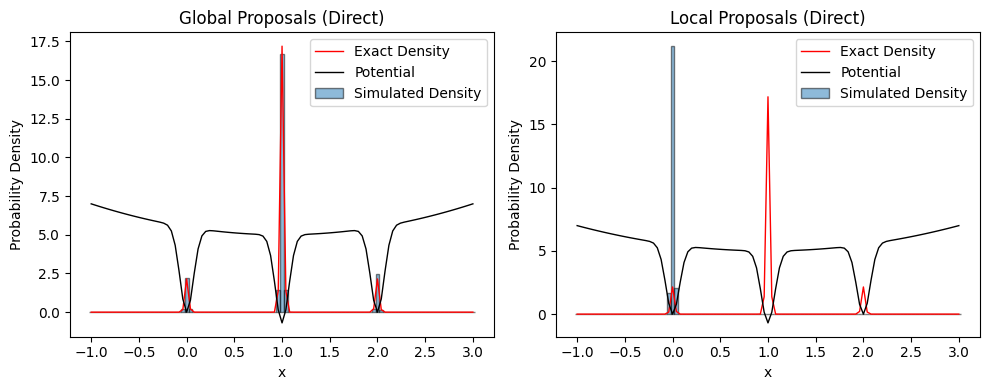

In [11]:
class LocalMetro(DiscretizedSpaceMetro):
    def propose(self):
        # Find the index of the current state on the grid
        idx = np.argmin(np.abs(self.grid - self.state))
        
        # Propose stepping left (-1) or right (+1) with equal probability
        step = np.random.choice([-1, 1])
        new_idx = idx + step
        
        # Apply boundary conditions: if it steps outside, stay at the boundary
        if new_idx < 0:
            new_idx = 0
        elif new_idx >= len(self.grid):
            new_idx = len(self.grid) - 1
            
        return self.grid[new_idx]


class ImportanceSamplingMetro(DiscretizedSpaceMetro):
    def _exp(self, x, y):
        # Sample only from the reference potential V0(x)
        # This forces the Metropolis algorithm to sample the P0(x) distribution
        return np.exp(-1/self.kbT * (self.V0(y) - self.V0(x)))

    def reweighted_avg_V(self):
        if not hasattr(self, 'history'): 
            raise Exception('Simulation not run')
        
        V_full = self.V(self.history)
        delta_V_hist = self.delta_V(self.history)
        
        weights = np.exp(-delta_V_hist / self.kbT)
        
        # Ratio of expectations under P0
        numerator = np.mean(V_full * weights)
        denominator = np.mean(weights)
        
        return numerator / denominator



# Global (Direct) Sampling
sim_global = DiscretizedSpaceMetro(N_points=101)
sim_global.run_simulation()
expected_V_global = np.mean(sim_global.V(sim_global.history))

# Local Sampling
sim_local = LocalMetro(N_points=101)
sim_local.run_simulation()
expected_V_local = np.mean(sim_local.V(sim_local.history))

# Importance Sampling
sim_importance = ImportanceSamplingMetro(N_points=101)
sim_importance.run_simulation()
expected_V_importance = sim_importance.reweighted_avg_V()

print("--- Thermal Average of V(x) ---")
print(f"1. Global Sampling (Direct):    {expected_V_global:.4f}")
print(f"2. Local Sampling (Direct):     {expected_V_local:.4f}")
print(f"3. Importance Sampling:         {expected_V_importance:.4f}")

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

sim_global.plot(axs[0])
axs[0].set_title("Global Proposals (Direct)")

sim_local.plot(axs[1])
axs[1].set_title("Local Proposals (Direct)")

plt.tight_layout()
plt.show()